In [56]:
import torch
import matplotlib.pyplot as plt
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient, loadMATLABGMM
import scipy.io
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [57]:
# ─── Parameters ────────────────────────────────────────────────
R = .5                     # Circle radius
dt = .5e-3             # Time step
num_steps = 6000           # Total steps
T = num_steps * dt          # Total time
num_particles = 5*10**5       # Reduced for performance
small_region_radius = 0.012  # Increased radius


In [58]:
x0 = [-1.077584687836405, -1.143662028308047, -1.970947232641746, -1.095393482824536,-1.324569745777624, -1.224993591727765]
y0 = [1.013873219540146, 1.063292040954886, -0.118626742471576, -0.901418656399284, -0.908996126946099, 1.059285353948204]
small_region_centers = torch.tensor(list(zip(x0, y0)), device=device)

In [59]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
weightsX0, mu_X0, covariances_X0 = loadMATLABGMM("/home/klaas/Documents/codes/MLSPointSetRegistration/matlab/simulations/PSRAcrossCylinder/DistributionData.mat", "gmm0Struct", device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf, mu_Xinf, covariances_Xinf = loadMATLABGMM("/home/klaas/Documents/codes/MLSPointSetRegistration/matlab/simulations/PSRAcrossCylinder/DistributionData.mat", "gmmInfStruct", device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

In [60]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [61]:
# Ensure no particles start inside the circle
norms = torch.norm(positions, dim=1)
inside = norms < R
if inside.any():
    positions[inside] = R * positions[inside] / norms[inside].unsqueeze(1)

# Select particles in the small region
centers = small_region_centers.size(0)
masks = torch.empty((num_particles, centers), dtype=torch.bool, device=device)
for center in range(centers):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks[:, center] = distances < small_region_radius
    num_selected = masks[:, center].sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()

# List to store average positions of selected particles
avg_positions = []
avg_pos = (masks.float().T @ positions) / masks.float().sum(dim=0).clamp(min=1).unsqueeze(1)
avg_positions.append(avg_pos)

Number of particles in small region: 381
Number of particles in small region: 523
Number of particles in small region: 355
Number of particles in small region: 404
Number of particles in small region: 289
Number of particles in small region: 301


In [62]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, R)
final_positions, big_tensor = doSimulation(positions, masks, avg_positions, simParams, device)

t = 0.0000  |  Max drift: 1841.7855  |  Mean drift: 1056.7875
t = 0.0250  |  Max drift: 168.7912  |  Mean drift: 40.7596
t = 0.0500  |  Max drift: 158.9983  |  Mean drift: 32.7314
t = 0.0750  |  Max drift: 156.7567  |  Mean drift: 28.5049
t = 0.1000  |  Max drift: 156.8193  |  Mean drift: 26.3939
t = 0.1250  |  Max drift: 153.1298  |  Mean drift: 25.2869
t = 0.1500  |  Max drift: 151.6971  |  Mean drift: 24.7505
t = 0.1750  |  Max drift: 166.3231  |  Mean drift: 24.3649
t = 0.2000  |  Max drift: 141.5547  |  Mean drift: 24.2469
t = 0.2250  |  Max drift: 149.6306  |  Mean drift: 24.0672
t = 0.2500  |  Max drift: 172.8313  |  Mean drift: 24.0495
t = 0.2750  |  Max drift: 140.1813  |  Mean drift: 23.9224
t = 0.3000  |  Max drift: 163.8764  |  Mean drift: 23.9442
t = 0.3250  |  Max drift: 152.1080  |  Mean drift: 23.9195
t = 0.3500  |  Max drift: 159.2796  |  Mean drift: 23.9041
t = 0.3750  |  Max drift: 160.1189  |  Mean drift: 23.8818
t = 0.4000  |  Max drift: 147.4408  |  Mean drift: 23

In [63]:
scipy.io.savemat("data/avgPaths.mat", {"avg_paths": big_tensor.cpu().numpy()})

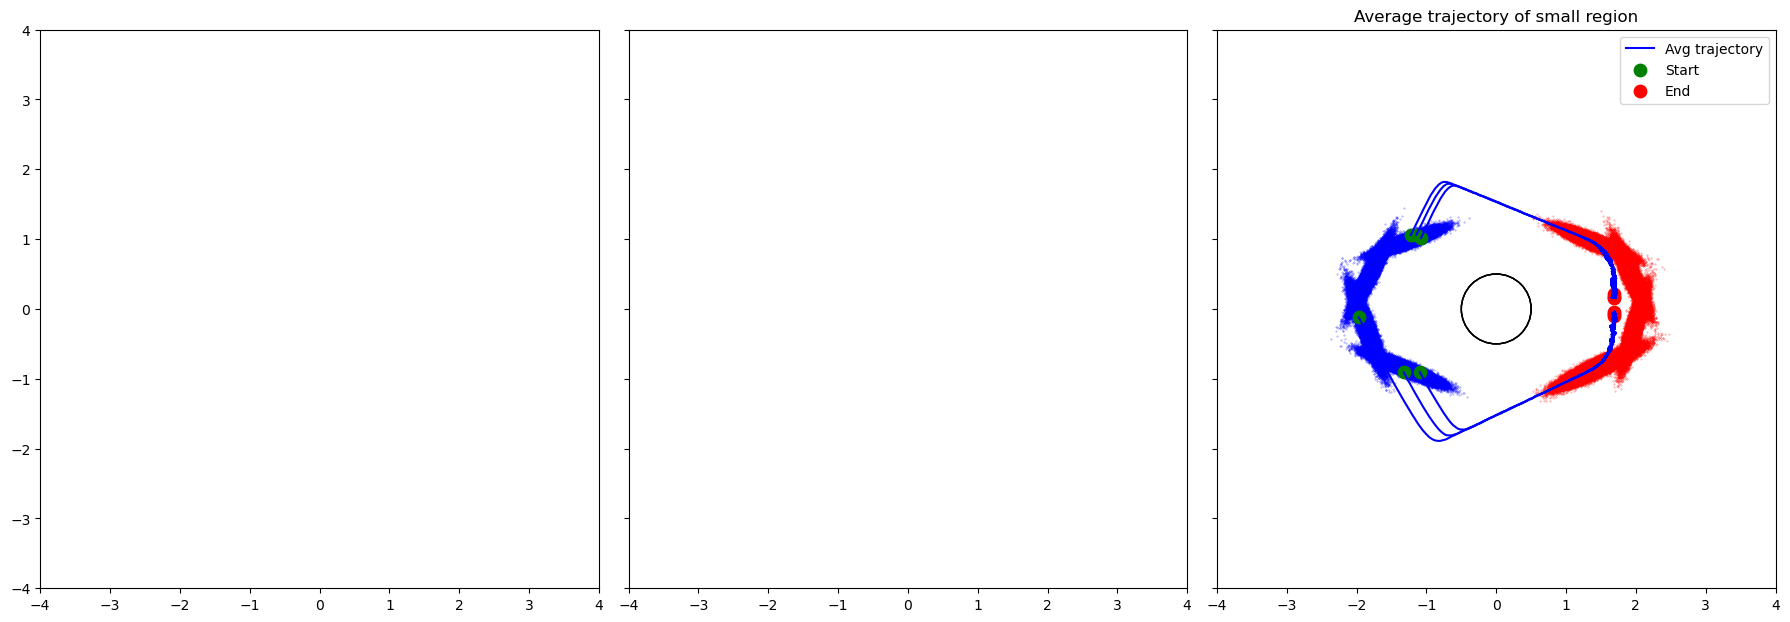

In [65]:
# ─── Plotting ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-4., 4.)
    ax.set_ylim(-4., 4.)

# Initial
axes[2].scatter(initial_positions[:,0], initial_positions[:,1], s=0.1, alpha=0.5, color='blue')
axes[2].set_title('Initial (X0 GMM)')
axes[2].add_patch(plt.Circle((0,0), R, color='black', fill=False))

# Final
axes[2].scatter(final_positions[:,0], final_positions[:,1], s=0.1, alpha=0.5, color='red')
axes[2].set_title('Final distribution')
axes[2].add_patch(plt.Circle((0,0), R, color='black', fill=False))

# Trajectory
for center in range(centers):
    axes[2].plot(big_tensor[:, center, 0], big_tensor[:, center, 1], 'b-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[2].scatter(big_tensor[0, center, 0], big_tensor[0, center, 1], color='green', s=80, label='Start'  if center == 0 else None)
    axes[2].scatter(big_tensor[-1, center, 0], big_tensor[-1, center, 1], color='red', s=80, label='End'  if center == 0 else None)
axes[2].add_patch(plt.Circle((0,0), R, color='black', fill=False))
axes[2].set_title('Average trajectory of small region')
axes[2].legend()

plt.savefig("PSRStochasticMethod.pdf")
plt.tight_layout()
plt.show()